# 0 - EDA (Visualisation des données, remise en contexte)

Via l'EDA on pourrait voir que :
- "age" a 50 valeurs aberrantes (age > 500 ans)
- "cholesterol" est fortement corrélé avec la target (r=0.82)
- "profession = Boulanger" → risque moyen 2x plus élevé
- "vitamin_D" a 30% de valeurs manquantes

Donc on pourra ajuster le preprocessing en conséquence
```python
def preprocess(X):
    X = remove_outliers(X, 'age', threshold=200)  # Grâce à l'EDA
    X = impute_missing(X, 'vitamin_D', strategy='median')  # Grâce à l'EDA
    # ...
```

In [76]:
import pandas as pd
import numpy as np
import seaborn as sns
sns.set_theme()   # active le style seaborn pour matplotlib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler, LabelEncoder

import matplotlib.pyplot as plt

## 1. Structure des données
Combien de schtroumpf ? combien de feature ? quel type de données ? valeurs manquantes ? doublons ? 

In [77]:
X_train = pd.read_csv('../data/data_labeled/X_train.csv')
y_train = pd.read_csv('../data/data_labeled/y_train.csv')
X_test = pd.read_csv('../data/data_labeled/X_test.csv')
y_test = pd.read_csv('../data/data_labeled/y_test.csv')
X_unlabeled = pd.read_csv('../data/data_unlabeled/X.csv')

print(f"Shape X_train: {X_train.shape}")
print(f"Shape y_train: {y_train.shape}")
print(f"Shape X_test: {X_test.shape}")
print(f"Shape y_test: {y_test.shape}")
print(f"Shape X_unlabeled: {X_unlabeled.shape}")

Shape X_train: (1000, 14)
Shape y_train: (999, 1)
Shape X_test: (500, 14)
Shape y_test: (499, 1)
Shape X_unlabeled: (500, 14)


**Visualisations:**

In [78]:
print("\nValeurs manquantes:")
print(X_train.isnull().sum())

X_train.describe()


Valeurs manquantes:
age                  0
blood pressure       0
calcium              0
cholesterol          0
hemoglobin           0
height               0
potassium            0
profession           0
sarsaparilla         0
smurfberry liquor    0
smurfin donuts       0
vitamin D            0
weight               0
img_filename         0
dtype: int64


,age,blood pressure,calcium,cholesterol,hemoglobin,height,potassium,vitamin D,weight
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,117.611000,108.402300,2.445580,111.997520,14.214560,7.59766,4.313280,30.173120,105.406230
std,30.169585,11.035291,0.205762,22.016259,2.051817,0.39668,0.505503,4.998889,16.907572
min,20.000000,84.930000,1.740000,45.680000,6.360000,6.39000,2.750000,14.340000,58.800000
25%,98.000000,100.765000,2.310000,97.427500,12.767500,7.32000,3.970000,27.097500,93.350000
50%,118.000000,106.085000,2.445000,110.980000,14.255000,7.59000,4.320000,30.285000,104.235000
75%,138.000000,114.017500,2.590000,126.107500,15.630000,7.86000,4.652500,33.315000,115.942500
max,180.000000,154.540000,3.100000,187.190000,20.880000,8.86000,5.850000,47.060000,160.400000


## 2. Quel target ?
- Quelle est la distribution du risque cardiaque ?
- La distribution est-elle normale ? Skewed ? 
- Quel est le range des valeurs ?
- Y a-t-il d'extreme genre "outliers" ?

<Figure size 1000x600 with 0 Axes>

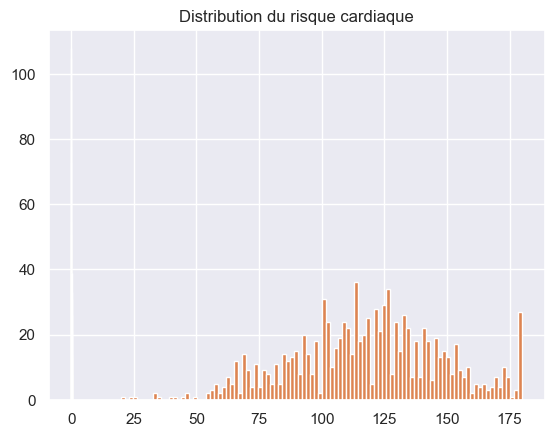

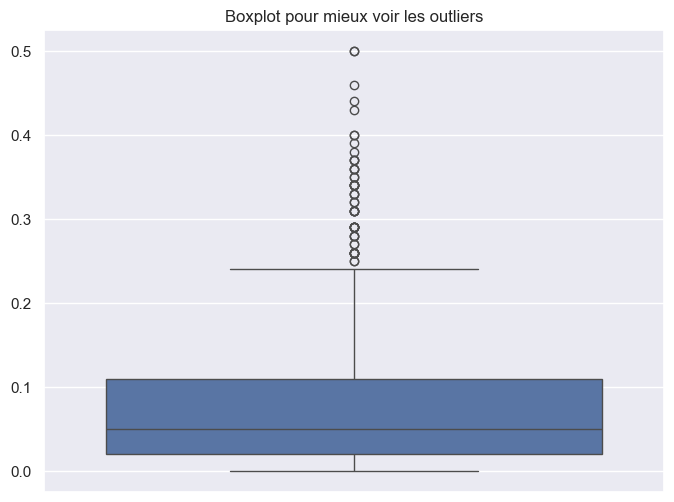

In [ ]:
plt.figure(figsize=(10, 6))
y_train.hist(bins= 50)
plt.title('Distribution du risque cardiaque')

plt.figure(figsize=(8, 6))
sns.boxplot(y=y_train.values.flatten())
plt.title('Boxplot pour mieux voir les outliers')
plt.show()

## 3. Feature numérique
### Questions
- Quelles features ont des outliers (donnée aberrante) ?
- Y a-t-il des corrélations entre features ? 
- Quelle feature est la plus corrélée avec la target (le risque de faire un arret cardiaque) ?
- Y a-t-il de la multicolinéarité ? (2 features trop similaires)

### Réponses

- Je sais pas ?
- Oui, il y a des corrélations entre weight et height, cholesterol et blood pressure, blood press et weight, weight et cholesterol
- Vitamine D
- Non, pour l'instant je pense que le seuil max c'est 0.85 de correlation et on est à la moitié là.

vitamin D        -0.051816
height            0.047352
weight           -0.041593
age               0.028062
blood pressure   -0.025056
potassium         0.012078
hemoglobin       -0.003509
calcium          -0.003249
cholesterol      -0.001169
Name: target, dtype: float64
Top 6 features les plus corrélées : ['vitamin D', 'height', 'weight', 'age', 'blood pressure', 'potassium']


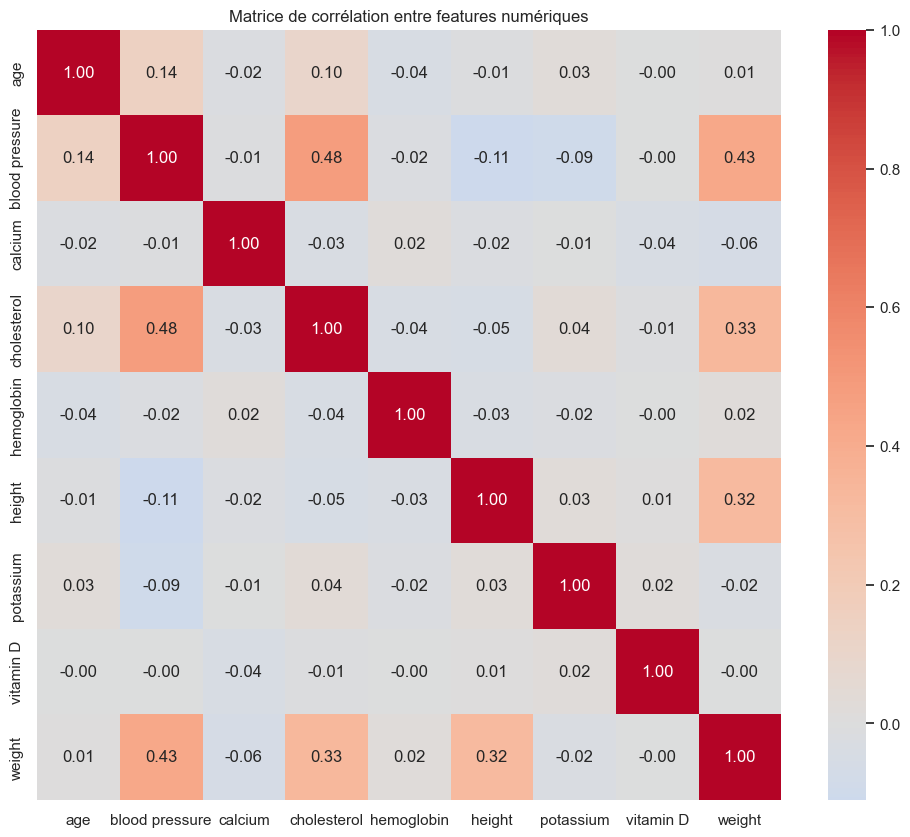

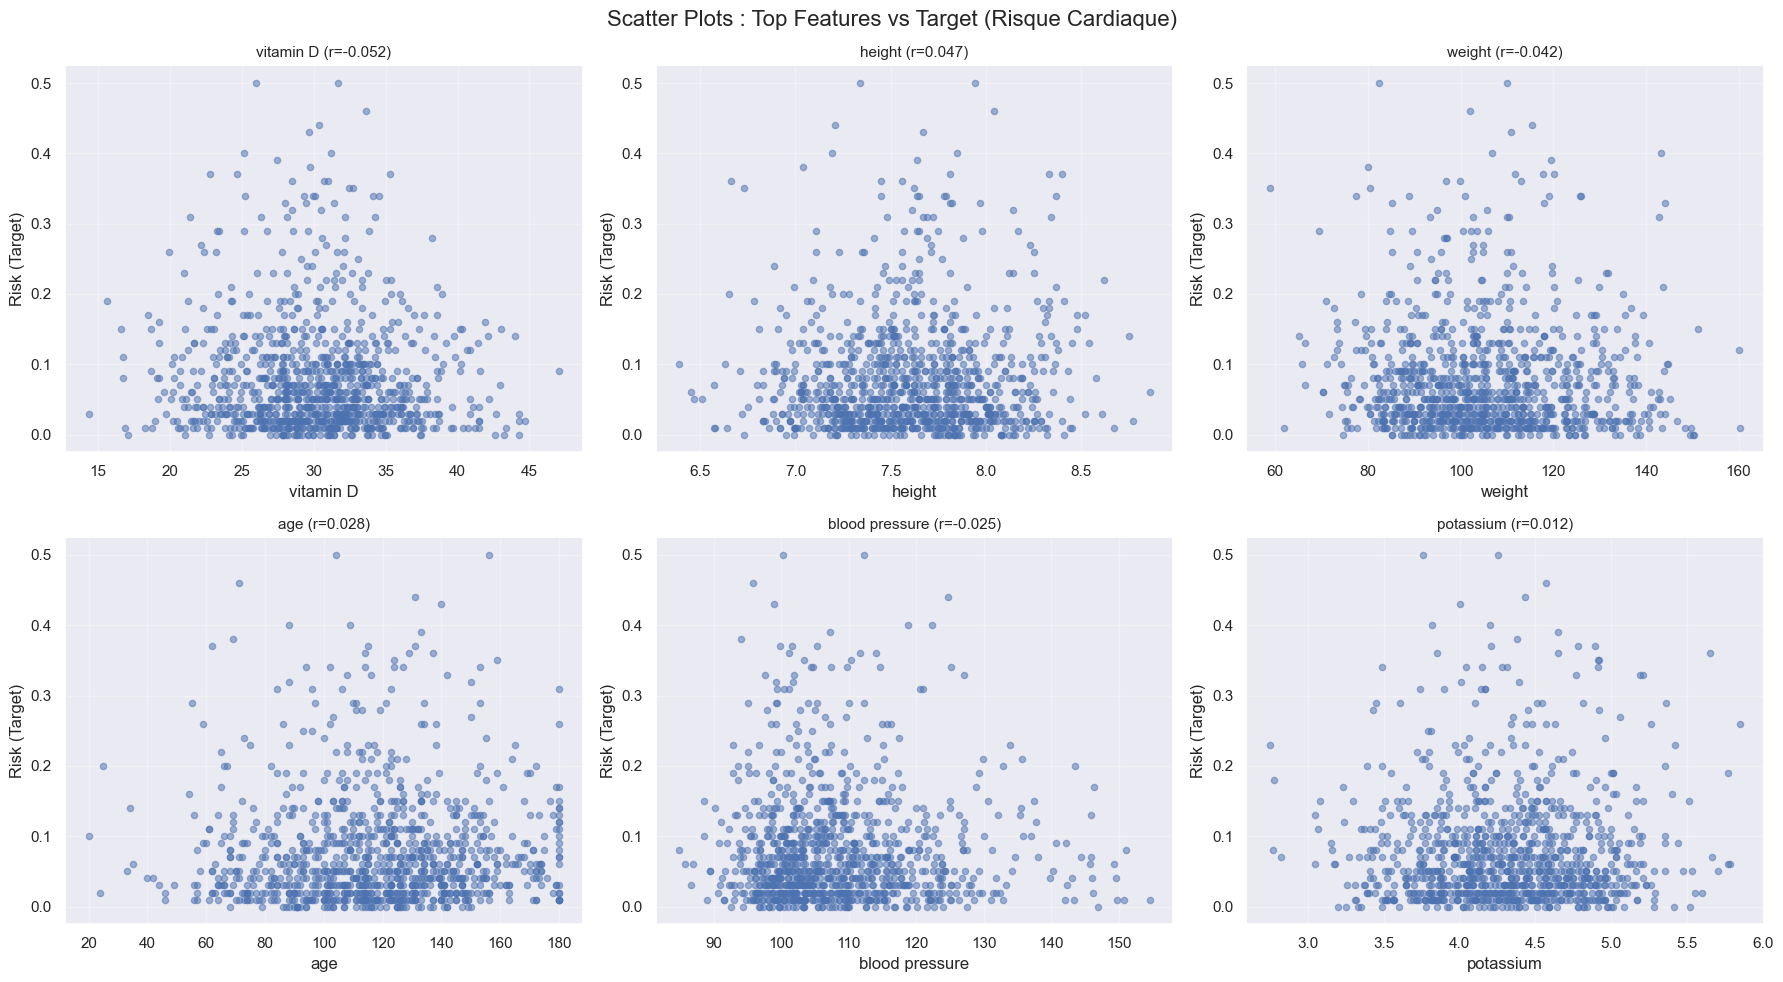

In [95]:
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = X_train[numeric_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Matrice de corrélation entre features numériques')

X_train_with_target = X_train.copy()
X_train_with_target['target'] = y_train
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
correlations_with_target = X_train_with_target[numeric_features + ['target']].corr()['target']
correlations_with_target = correlations_with_target.drop('target') # Pas avoir la correlation avec elle meme 
correlations_with_target = correlations_with_target.sort_values(key=abs, ascending=False)

print(correlations_with_target)

# Sélectionner les 6 features les plus corrélées
top_features = correlations_with_target.head(6).index.tolist()
print(f"Top 6 features les plus corrélées : {top_features}")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Scatter Plots : Top Features vs Target (Risque Cardiaque)', fontsize=16)
for i, feature in enumerate(top_features):
    ax = axes[i//3, i%3]
    
    # pcq il y a une différence de longueur
    n = min(len(X_train), len(y_train))
    ax.scatter(X_train[feature].iloc[:n], y_train.iloc[:n].squeeze(), alpha=0.5, s=20)
    ax.set_xlabel(feature, fontsize=12)
    ax.set_ylabel('Risk (Target)', fontsize=12)
    
    corr_value = correlations_with_target[feature]  
    ax.set_title(f'{feature} (r={corr_value:.3f})', fontsize=11)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Analyse categorical feature

### Questions :
- Combien de catégories dans "profession" ?
- Les distributions sont-elles équilibrées ?
- Y a-t-il des catégories rares (< 1% des données) ?
- Quel impact sur la target ?

<Axes: xlabel='profession'>

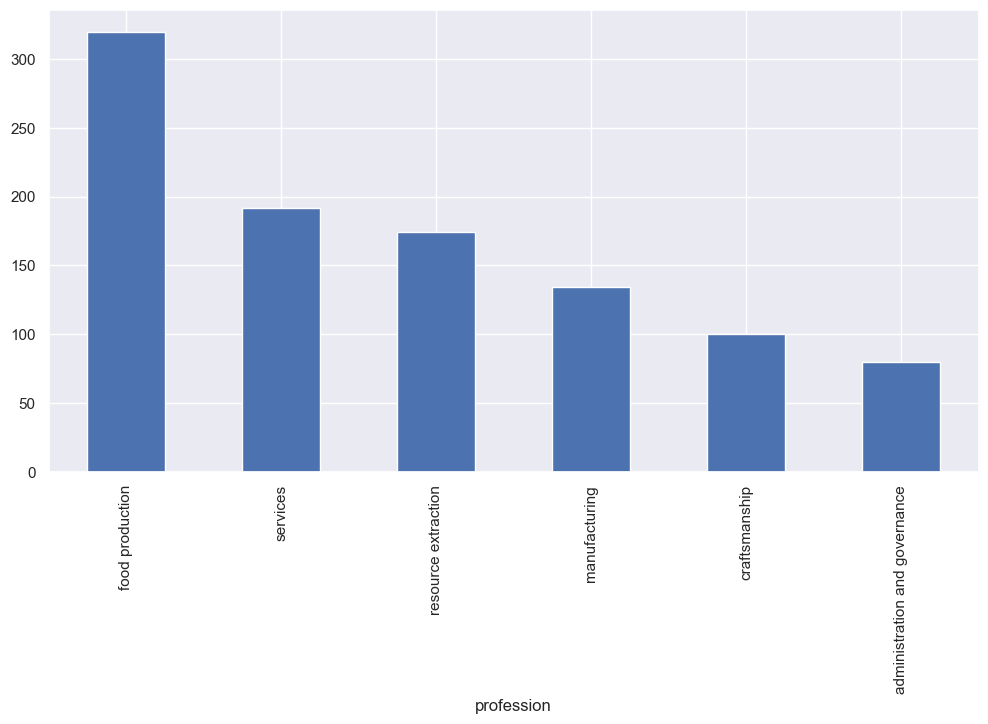

In [96]:
plt.figure(figsize=(12,6))
X_train['profession'].value_counts().plot(kind='bar')